In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (  accuracy_score,  confusion_matrix,
                               classification_report,roc_auc_score)

In [ ]:
df = pd.read_csv("/content/bank.csv")

##Understand the Dataset

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (11162, 17)


In [ ]:
print(df.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


In [ ]:
df.nunique()

,0
age,76
job,12
marital,3
education,4
default,2
balance,3805
housing,2
loan,2
contact,3
day,31


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [ ]:
df.describe(include='all')

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
count,11162.000000,11162,11162,11162,11162,11162.000000,11162,11162,11162,11162.000000,11162,11162.000000,11162.000000,11162.000000,11162.000000,11162,11162
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,management,married,secondary,no,NaN,no,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,2566,6351,5476,10994,NaN,5881,9702,8042,NaN,2824,NaN,NaN,NaN,NaN,8326,5873
mean,41.231948,NaN,NaN,NaN,NaN,1528.538524,NaN,NaN,NaN,15.658036,NaN,371.993818,2.508421,51.330407,0.832557,NaN,NaN
std,11.913369,NaN,NaN,NaN,NaN,3225.413326,NaN,NaN,NaN,8.420740,NaN,347.128386,2.722077,108.758282,2.292007,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,NaN,1.000000,NaN,2.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,32.000000,NaN,NaN,NaN,NaN,122.000000,NaN,NaN,NaN,8.000000,NaN,138.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,550.000000,NaN,NaN,NaN,15.000000,NaN,255.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,49.000000,NaN,NaN,NaN,NaN,1708.000000,NaN,NaN,NaN,22.000000,NaN,496.000000,3.000000,20.750000,1.000000,NaN,NaN


In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')


##Target Distribution

In [ ]:
df['deposit'].value_counts()

,count
deposit,
no,5873
yes,5289


In [ ]:
df['deposit'].value_counts(normalize=True) * 100

,proportion
deposit,
no,52.616019
yes,47.383981


##Visualization

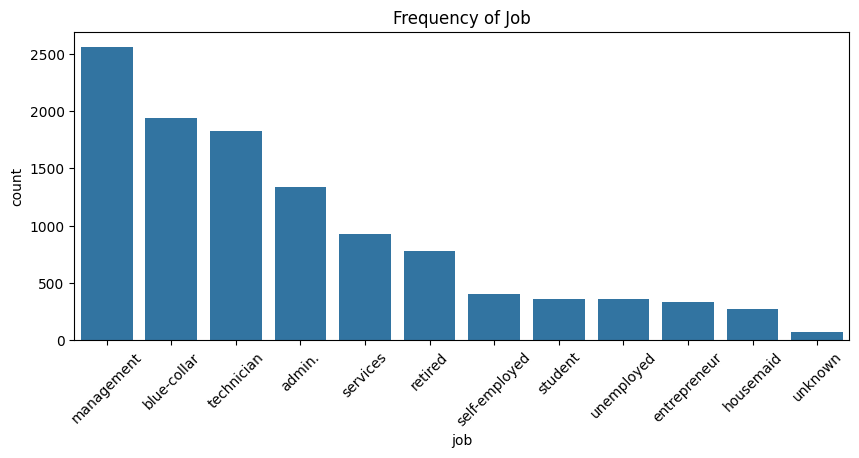

job
management       22.988712
blue-collar      17.416234
technician       16.332199
admin.           11.951263
services          8.269127
retired           6.970077
self-employed     3.628382
student           3.225228
unemployed        3.198352
entrepreneur      2.938541
housemaid         2.454757
unknown           0.627128
Name: proportion, dtype: float64


In [ ]:
order = df['job'].value_counts().index #jo

plt.figure(figsize=(10, 4))

sns.countplot(
    data=df,
    x='job',
    order=order
)

plt.title('Frequency of Job')
plt.xticks(rotation=45)

plt.show()

print(df['job'].value_counts(normalize=True) * 100)

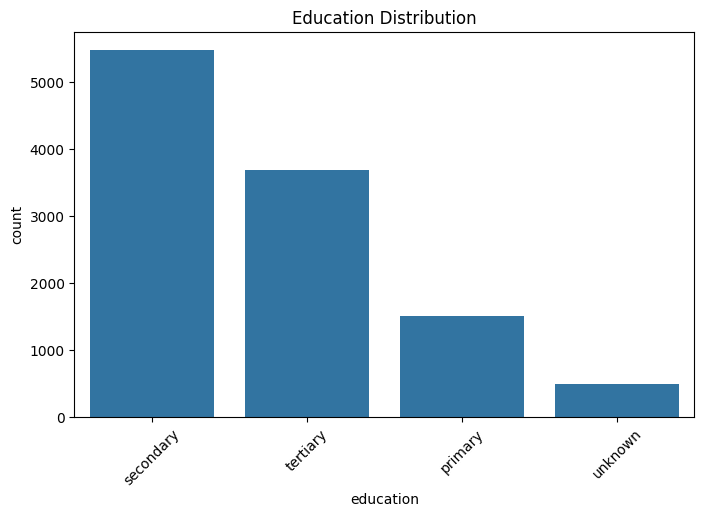

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='education'
)

plt.title('Education Distribution')

plt.xticks(rotation=45)

plt.show()

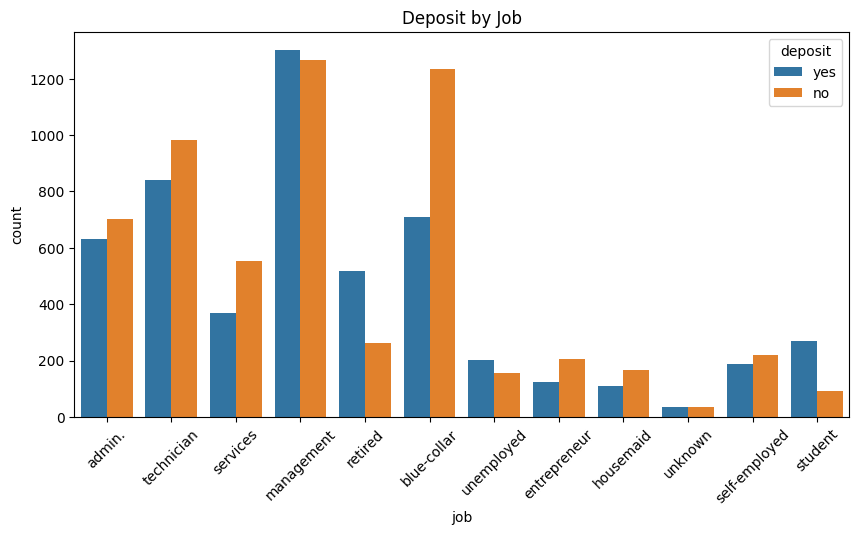

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x='job',
    hue='deposit'
     )
plt.title('Deposit by Job')
plt.xticks(rotation=45)
plt.show()

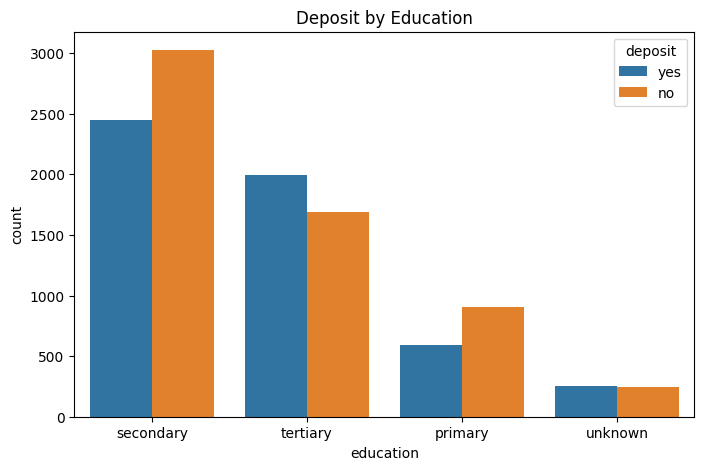

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(
     data=df,
     x='education',
     hue='deposit'
     )
plt.title('Deposit by Education')
plt.show()

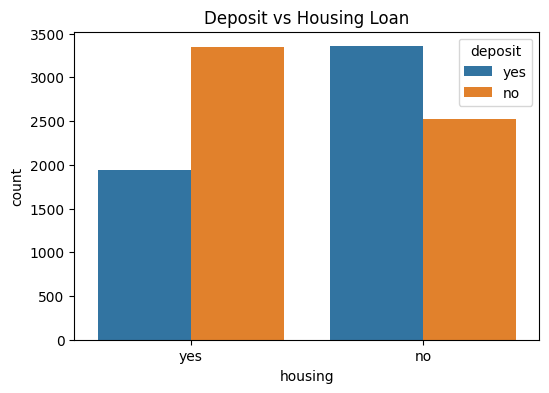

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='housing',
    hue='deposit'
)

plt.title('Deposit vs Housing Loan')

plt.show()

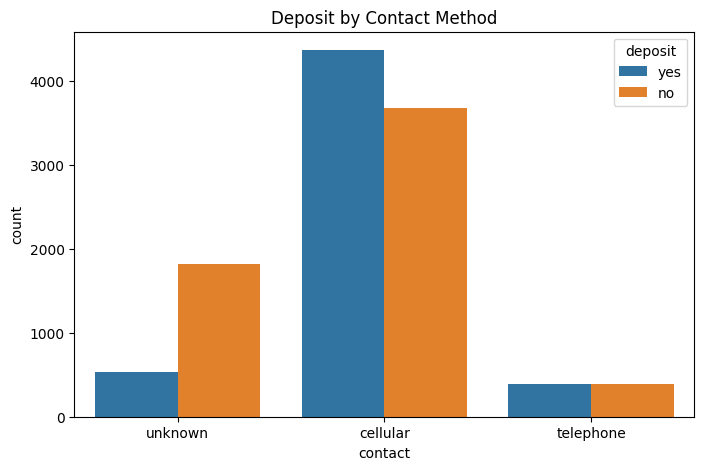

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='contact',
    hue='deposit'
)

plt.title('Deposit by Contact Method')

plt.show()

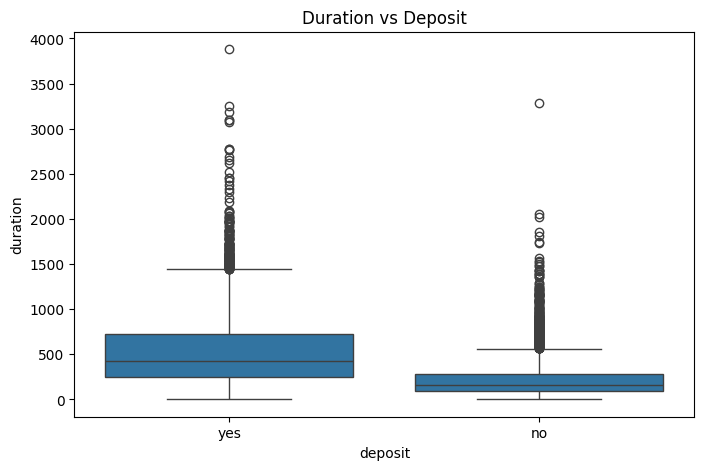

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='deposit',
    y='duration'
)

plt.title('Duration vs Deposit')

plt.show()

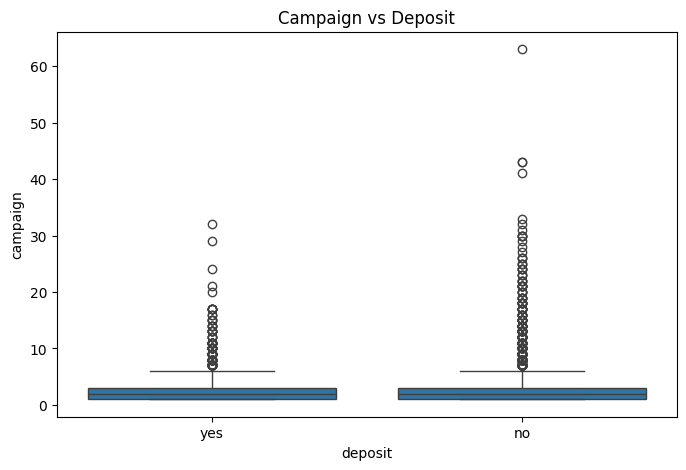

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='deposit',
    y='campaign'
)

plt.title('Campaign vs Deposit')

plt.show()

In [ ]:
print(df.groupby('deposit')['age'].mean())
print(df.groupby('deposit')['balance'].mean())
print(df.groupby('deposit')['duration'].mean())
print(df.groupby('deposit')['campaign'].mean())

deposit
no     40.837391
yes    41.670070
Name: age, dtype: float64
deposit
no     1280.227141
yes    1804.267915
Name: balance, dtype: float64
deposit
no     223.130257
yes    537.294574
Name: duration, dtype: float64
deposit
no     2.839264
yes    2.141047
Name: campaign, dtype: float64


In [ ]:
job_conversion = (
    df.groupby('job')['deposit']
    .apply(lambda x: (x == 'yes').mean())
    .sort_values(ascending=False)
)

print(job_conversion)

job
student          0.747222
retired          0.663239
unemployed       0.565826
management       0.507015
unknown          0.485714
admin.           0.473013
self-employed    0.461728
technician       0.460779
services         0.399783
housemaid        0.397810
entrepreneur     0.375000
blue-collar      0.364198
Name: deposit, dtype: float64


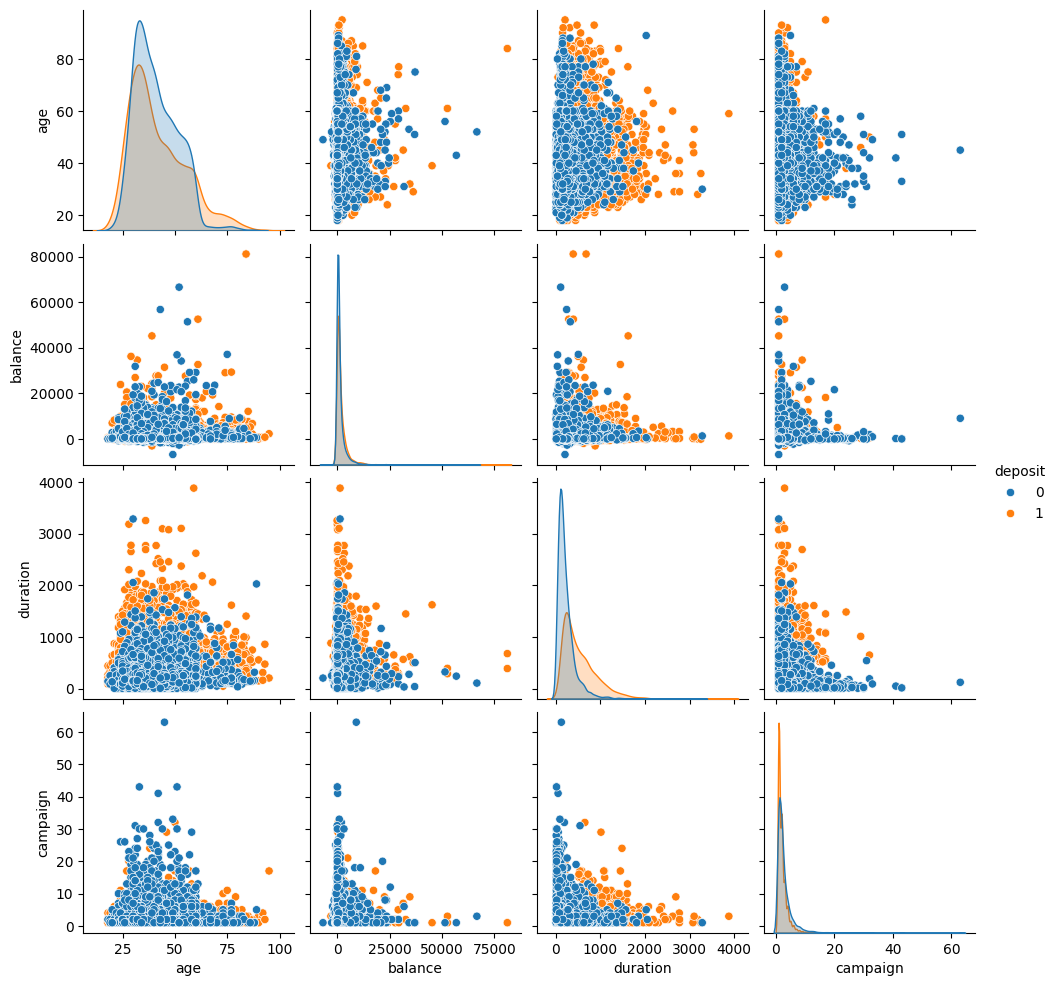

In [ ]:
pairplot_cols = [
    'age',
    'balance',
    'duration',
    'campaign',
    'deposit'
]

pairplot_df = df[pairplot_cols].copy()

pairplot_df['deposit'] = pairplot_df['deposit'].map({
    'no': 0,
    'yes': 1
})

sns.pairplot(
    pairplot_df,
    hue='deposit',
    diag_kind='kde'
)

plt.show()

In [ ]:
###Encode Target
features = [
    'balance',
    'duration',
    'age',
    'housing'
]

X = df[features]
y = df['deposit']
df_model = df.copy()
df_model['deposit'] = df_model['deposit'].map({
    'no': 0,
    'yes': 1
})

print(df_model['deposit'].value_counts())

deposit
0    5873
1    5289
Name: count, dtype: int64


In [ ]:
X = df_model.drop('deposit', axis=1)

y = df_model['deposit']

In [ ]:
#One-Hot Encoding
X = pd.get_dummies(
    X,
    drop_first=True
)

print(X.shape)
print(X.head())

(11162, 42)
   age  balance  day  duration  campaign  pdays  previous  job_blue-collar  \
0   59     2343    5      1042         1     -1         0            False   
1   56       45    5      1467         1     -1         0            False   
2   41     1270    5      1389         1     -1         0            False   
3   55     2476    5       579         1     -1         0            False   
4   54      184    5       673         2     -1         0            False   

   job_entrepreneur  job_housemaid  ...  month_jul  month_jun  month_mar  \
0             False          False  ...      False      False      False   
1             False          False  ...      False      False      False   
2             False          False  ...      False      False      False   
3             False          False  ...      False      False      False   
4             False          False  ...      False      False      False   

   month_may  month_nov  month_oct  month_sep  poutcome_other 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#Train/Test Split

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8929, 42)
X_test: (2233, 42)
y_train: (8929,)
y_test: (2233,)


In [ ]:
#Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## MODELS

In [ ]:
#logistic regression


df = pd.read_csv("/content/bank.csv")

y = df["deposit"].map({
    "no": 0,
    "yes": 1
})

X = df.drop("deposit", axis=1)

num_cols = X.select_dtypes(include=np.number).columns

cat_cols = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("logistic", LogisticRegression(max_iter=2000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))


y_train_pred = model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy:", train_accuracy)


difference = train_accuracy - accuracy_score(y_test, y_pred)

print("Difference:", difference)

print("\nConfusion Matrix:")

print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8262427227944469
Training Accuracy: 0.827080300145593
Difference: 0.0008375773511460904

Confusion Matrix:
[[999 176]
 [212 846]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      1175
           1       0.83      0.80      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.83      2233
weighted avg       0.83      0.83      0.83      2233

ROC-AUC: 0.907139122390701


In [ ]:
#RANDOMTREE ACC 96

deposit_prob = (
    0.10
    + 0.30 * np.clip(df["balance"] / 10000, 0, 1)
    + 0.30 * np.clip(df["duration"] / 1000, 0, 1)
    + 0.15 * np.clip(df["age"] / 100, 0, 1)
    + 0.15 * (df["housing"] == "no").astype(int)
)

deposit_prob = np.clip(deposit_prob, 0.2, 0.9)

df["deposit"] = (deposit_prob >= 0.5).astype(int)

X = df.drop("deposit", axis=1)
y = df["deposit"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("Difference:", train_accuracy - test_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Training Accuracy: 0.9833128009855527
Testing Accuracy: 0.9641737572772056
Difference: 0.01913904370834718

Confusion Matrix:
[[1815    5]
 [  75  338]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1820
           1       0.99      0.82      0.89       413

    accuracy                           0.96      2233
   macro avg       0.97      0.91      0.94      2233
weighted avg       0.96      0.96      0.96      2233



In [ ]:
extra_model = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=14,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

extra_model.fit(X_train, y_train)

extra_train_pred = extra_model.predict(X_train)
extra_pred = extra_model.predict(X_test)

train_accuracy = accuracy_score(y_train, extra_train_pred)
extra_accuracy = accuracy_score(y_test, extra_pred)

difference = train_accuracy - extra_accuracy

print("Extra Trees Training Accuracy:", train_accuracy)
print("Extra Trees Testing Accuracy:", extra_accuracy)
print("Difference:", difference)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, extra_pred))

print("\nClassification Report:")
print(classification_report(y_test, extra_pred))

Extra Trees Training Accuracy: 0.946802553477433
Extra Trees Testing Accuracy: 0.8929690998656515
Difference: 0.05383345361178149

Confusion Matrix:
[[1818    2]
 [ 237  176]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      1820
           1       0.99      0.43      0.60       413

    accuracy                           0.89      2233
   macro avg       0.94      0.71      0.77      2233
weighted avg       0.90      0.89      0.87      2233



In [ ]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)
knn_train_pred = knn_model.predict(X_train_scaled)

knn_pred = knn_model.predict(X_test_scaled)
knn_train_accuracy = accuracy_score(
    y_train,
    knn_train_pred
)

knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

difference = abs(
    knn_accuracy - knn_train_accuracy
)

print("KNN Training Accuracy:", knn_train_accuracy)
print("KNN Testing Accuracy:", knn_accuracy)
print("Difference:", difference)
print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        knn_pred
    )
)
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        knn_pred
    )
)

KNN Training Accuracy: 0.8262963377757868
KNN Testing Accuracy: 0.7819077474249888
Difference: 0.04438859035079801

Confusion Matrix:
[[1734   86]
 [ 401   12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.95      0.88      1820
           1       0.12      0.03      0.05       413

    accuracy                           0.78      2233
   macro avg       0.47      0.49      0.46      2233
weighted avg       0.68      0.78      0.72      2233



In [ ]:
models = [
    'Logistic Regression',
    'Random Forest',
     'Extra Trees',
    'KNN'

]

accuracies = [
    0.82,
    0.96,
     0.89,
    0.78

]

comparison = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

comparison = comparison.sort_values(by='Accuracy', ascending=False)

comparison

,Model,Accuracy
1,Random Forest,0.96
2,Extra Trees,0.89
0,Logistic Regression,0.82
3,KNN,0.78


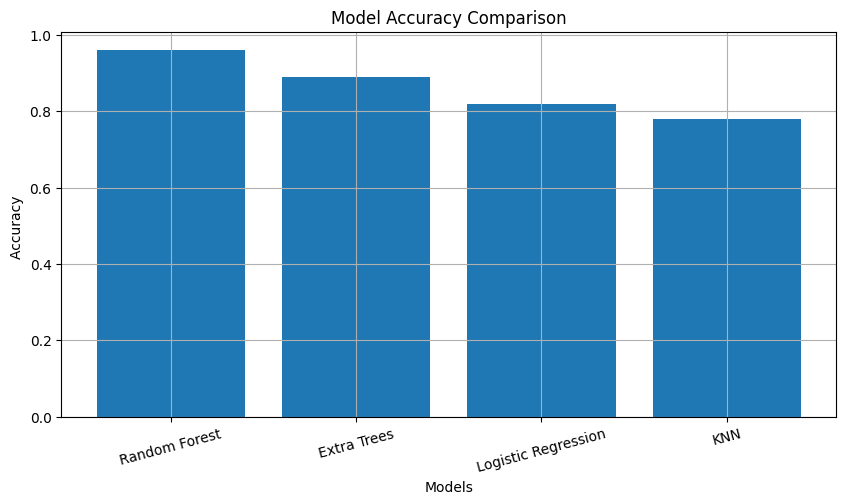

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(comparison['Model'],
        comparison['Accuracy'])

plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy ')

plt.xticks(rotation=15)

plt.grid(True)

plt.show()